In [1]:
# Cell 1: imports
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
IMAGENET_TRAIN_DIR = Path("/imagenet/train")  # <- change this
assert IMAGENET_TRAIN_DIR.exists(), f"Directory not found: {IMAGENET_TRAIN_DIR}"

In [4]:
# Cell 3: define parent categories using WNIDs
parent_categories = {
    "airplane": [
        "n02690373",  # airliner
    ],
    "bear": [
        "n02132136",  # brown_bear
        "n02133161",  # American_black_bear
        "n02134084",  # ice_bear
        "n02134418",  # sloth_bear
    ],
    "bicycle": [
        "n02835271",  # bicycle-built-for-two
        "n03792782",  # mountain_bike
    ],
    "bird": [
        "n01795545", "n01796340", "n01797886", "n01798484", "n01806143",
        "n01806567", "n01807496", "n01817953", "n01818515", "n01819313",
        "n01820546", "n01824575", "n01828970", "n01829413", "n01833805",
        "n01843065", "n01843383", "n01847000", "n01855032", "n01855672",
        "n01860187", "n02002556", "n02002724", "n02006656", "n02007558",
        "n02009229", "n02009912", "n02011460", "n02012849", "n02013706",
        "n02017213", "n02018207", "n02018795", "n02025239", "n02027492",
        "n02028035", "n02033041", "n02037110", "n02051845", "n02056570",
        "n02058221", "n01514668", "n01514859", "n01518878", "n01530575",
        "n01531178", "n01532829", "n01534433", "n01537544", "n01558993",
        "n01560419", "n01580077", "n01582220", "n01592084", "n01601694",
        "n01608432", "n01614925", "n01616318", "n01622779",
    ],
    "boat": [
        "n02951358",  # canoe
        "n03344393",  # fireboat
        "n03447447",  # gondola
        "n03662601",  # lifeboat
        "n04273569",  # speedboat
        "n04612504",  # yawl
        "n02981792",  # catamaran
        "n04483307",  # trimaran
        "n03095699",  # container_ship
        "n03673027",  # liner
        "n02687172",  # aircraft_carrier
        "n04347754",  # submarine
        "n04147183",  # schooner
    ],
    "bottle": [
        "n02823428",  # beer_bottle
        "n02877765",  # bottlecap
        "n03983396",  # pop_bottle
        "n03937543",  # pill_bottle
        "n04591713",  # wine_bottle
        "n04557648",  # water_bottle
        "n04560804",  # water_jug
    ],
    "car": [
        "n02814533",  # beach_wagon
        "n02930766",  # cab
        "n03100240",  # convertible
        "n03594945",  # jeep
        "n03670208",  # limousine
        "n03770679",  # minivan
        "n03777568",  # Model_T
        "n04037443",  # racer
        "n04285008",  # sports_car
    ],
    "cat": [
        "n02123045",  # tabby
        "n02123159",  # tiger_cat
        "n02123394",  # Persian_cat
        "n02123597",  # Siamese_cat
        "n02124075",  # Egyptian_cat
        "n02125311",  # cougar
    ],
    "chair": [
        "n02791124",  # barber_chair
        "n03376595",  # folding_chair
        "n04099969",  # rocking_chair
        "n04429376",  # throne
    ],
    "clock": [
        "n02708093",  # analog_clock
        "n03196217",  # digital_clock
        "n04548280",  # wall_clock
    ],
    "dog": [
        "n02085620", "n02085782", "n02085936", "n02086079", "n02086240",
        "n02086646", "n02086910", "n02087046", "n02087394", "n02088094",
        "n02088238", "n02088364", "n02088466", "n02088632", "n02089078",
        "n02089867", "n02089973", "n02090379", "n02090622", "n02090721",
        "n02091032", "n02091134", "n02091244", "n02091467", "n02091635",
        "n02091831", "n02092002", "n02092339", "n02093256", "n02093428",
        "n02093647", "n02093754", "n02093859", "n02093991", "n02094114",
        "n02094258", "n02094433", "n02095314", "n02095570", "n02095889",
        "n02096051", "n02096177", "n02096294", "n02096437", "n02096585",
        "n02097047", "n02097130", "n02097209", "n02097298", "n02097474",
        "n02097658", "n02098105", "n02098286", "n02098413", "n02099267",
        "n02099429", "n02099601", "n02099712", "n02099849", "n02100236",
        "n02100583", "n02100735", "n02100877", "n02101006", "n02101388",
        "n02101556", "n02102040", "n02102177", "n02102318", "n02102480",
        "n02102973", "n02104029", "n02104365", "n02105056", "n02105162",
        "n02105251", "n02105412", "n02105505", "n02105641", "n02105855",
        "n02106030", "n02106166", "n02106382", "n02106550", "n02106662",
        "n02107142", "n02107312", "n02107574", "n02107683", "n02107908",
        "n02108000", "n02108089", "n02108422", "n02108551", "n02108915",
        "n02109047", "n02109525", "n02109961", "n02110063", "n02110185",
        "n02110341", "n02110627", "n02110806", "n02110958", "n02111129",
        "n02111277", "n02111500", "n02111889", "n02112018", "n02112137",
        "n02112350", "n02112706", "n02113023", "n02113186", "n02113624",
        "n02113712", "n02113799", "n02113978",
    ],
    "elephant": [
        "n02504013",  # Indian_elephant
        "n02504458",  # African_elephant
    ],
    "keyboard": [
        "n03085013",  # computer_keyboard
        "n04505470",  # typewriter_keyboard
    ],
    "knife": [
        "n03041632",  # cleaver
    ],
    "oven": [
        "n04111531",  # rotisserie
    ],
    "truck": [
        "n03345487",  # fire_engine
        "n03417042",  # garbage_truck
        "n03770679",  # minivan
        "n03796401",  # moving_van
        "n03930630",  # pickup
        "n03977966",  # police_van
        "n04461696",  # tow_truck
        "n04467665",  # trailer_truck
    ],
}

In [6]:
# Cell 4: optional WNID -> readable class name mapping for display
wnid_to_name = {
    "n02690373": "airliner",
    "n02132136": "brown_bear",
    "n02133161": "American_black_bear",
    "n02134084": "ice_bear",
    "n02134418": "sloth_bear",
    "n02835271": "bicycle-built-for-two",
    "n03792782": "mountain_bike",
    "n02123045": "tabby",
    "n02123159": "tiger_cat",
    "n02123394": "Persian_cat",
    "n02123597": "Siamese_cat",
    "n02124075": "Egyptian_cat",
    "n02125311": "cougar",
    "n02504013": "Indian_elephant",
    "n02504458": "African_elephant",
    "n03085013": "computer_keyboard",
    "n04505470": "typewriter_keyboard",
    "n03041632": "cleaver",
    "n04111531": "rotisserie",
    "n03345487": "fire_engine",
    "n03417042": "garbage_truck",
    "n03770679": "minivan",
    "n03796401": "moving_van",
    "n03930630": "pickup",
    "n03977966": "police_van",
    "n04461696": "tow_truck",
    "n04467665": "trailer_truck",
}

In [8]:
# Cell 5: count images per WNID folder in the training set
valid_suffixes = {".jpg", ".jpeg", ".png", ".JPEG"}

class_counts = {}

for class_dir in IMAGENET_TRAIN_DIR.iterdir():
    if class_dir.is_dir():
        wnid = class_dir.name
        num_images = sum(
            1 for p in class_dir.iterdir()
            if p.is_file() and p.suffix in valid_suffixes
        )
        class_counts[wnid] = num_images

class_counts_df = (
    pd.DataFrame(
        [{"wnid": wnid, "count": count} for wnid, count in class_counts.items()]
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

class_counts_df.head(10)

,wnid,count
0,n02110806,1300
1,n01872401,1300
2,n02108915,1300
3,n04355338,1300
4,n04147183,1300
5,n04044716,1300
6,n02092339,1300
7,n02454379,1300
8,n03804744,1300
9,n01728572,1300


In [9]:
# Cell 6: show counts for the WNIDs used in your parent categories
rows = []
for parent, wnids in parent_categories.items():
    for wnid in wnids:
        rows.append({
            "parent_category": parent,
            "wnid": wnid,
            "class_name": wnid_to_name.get(wnid, wnid),
            "count": class_counts.get(wnid, 0),
        })

selected_classes_df = pd.DataFrame(rows).sort_values(
    ["parent_category", "count"], ascending=[True, False]
).reset_index(drop=True)

selected_classes_df

,parent_category,wnid,class_name,count
0,airplane,n02690373,airliner,1300
1,bear,n02132136,brown_bear,1300
2,bear,n02133161,American_black_bear,1300
3,bear,n02134084,ice_bear,1300
4,bear,n02134418,sloth_bear,1300
...,...,...,...,...
235,truck,n03930630,pickup,1300
236,truck,n03977966,police_van,1300
237,truck,n04461696,tow_truck,1300
238,truck,n04467665,trailer_truck,1300


In [10]:
# Cell 6: show counts for the WNIDs used in your parent categories
rows = []
for parent, wnids in parent_categories.items():
    for wnid in wnids:
        rows.append({
            "parent_category": parent,
            "wnid": wnid,
            "class_name": wnid_to_name.get(wnid, wnid),
            "count": class_counts.get(wnid, 0),
        })

selected_classes_df = pd.DataFrame(rows).sort_values(
    ["parent_category", "count"], ascending=[True, False]
).reset_index(drop=True)

selected_classes_df

,parent_category,wnid,class_name,count
0,airplane,n02690373,airliner,1300
1,bear,n02132136,brown_bear,1300
2,bear,n02133161,American_black_bear,1300
3,bear,n02134084,ice_bear,1300
4,bear,n02134418,sloth_bear,1300
...,...,...,...,...
235,truck,n03930630,pickup,1300
236,truck,n03977966,police_van,1300
237,truck,n04461696,tow_truck,1300
238,truck,n04467665,trailer_truck,1300


In [11]:
# Cell 7: aggregate counts per parent category
parent_counts = []
for parent, wnids in parent_categories.items():
    total = sum(class_counts.get(wnid, 0) for wnid in wnids)
    parent_counts.append({
        "parent_category": parent,
        "num_classes": len(wnids),
        "num_images": total,
    })

parent_counts_df = pd.DataFrame(parent_counts).sort_values(
    "num_images", ascending=False
).reset_index(drop=True)

parent_counts_df

,parent_category,num_classes,num_images
0,dog,118,147873
1,bird,59,76541
2,boat,13,16806
3,car,9,11700
4,truck,8,10259
5,bottle,7,9100
6,cat,6,7800
7,bear,4,5200
8,chair,4,4876
9,clock,3,3891


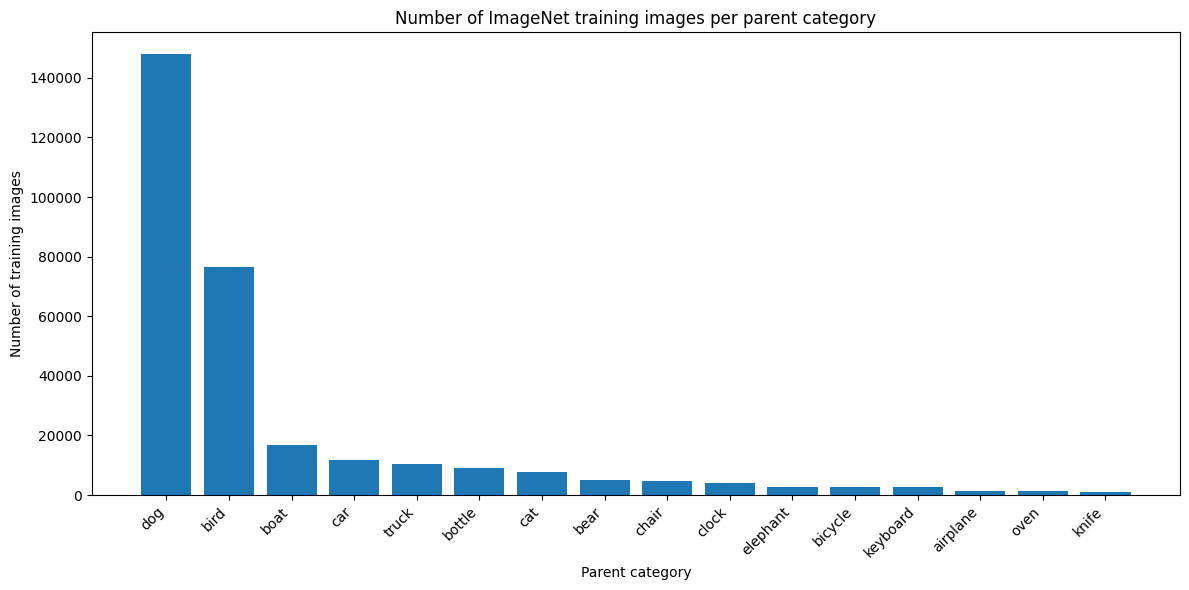

In [12]:
# Cell 8: visualize images per parent category
plt.figure(figsize=(12, 6))
plt.bar(parent_counts_df["parent_category"], parent_counts_df["num_images"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of training images")
plt.xlabel("Parent category")
plt.title("Number of ImageNet training images per parent category")
plt.tight_layout()
plt.show()

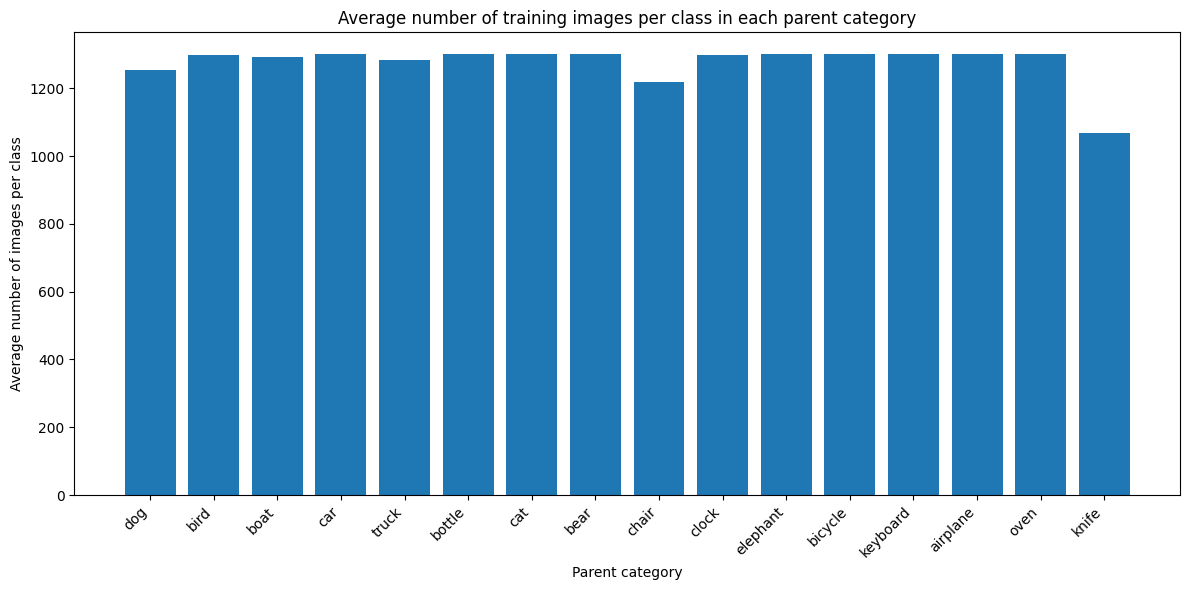

In [13]:
# Cell 9: optional visualization of average images per class within each parent category
parent_counts_df["avg_images_per_class"] = (
    parent_counts_df["num_images"] / parent_counts_df["num_classes"]
)

plt.figure(figsize=(12, 6))
plt.bar(parent_counts_df["parent_category"], parent_counts_df["avg_images_per_class"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average number of images per class")
plt.xlabel("Parent category")
plt.title("Average number of training images per class in each parent category")
plt.tight_layout()
plt.show()

In [14]:
# Cell 10: optional save results to csv
class_counts_df.to_csv("imagenet_class_counts.csv", index=False)
selected_classes_df.to_csv("imagenet_selected_class_counts.csv", index=False)
parent_counts_df.to_csv("imagenet_parent_category_counts.csv", index=False)

print("Saved:")
print(" - imagenet_class_counts.csv")
print(" - imagenet_selected_class_counts.csv")
print(" - imagenet_parent_category_counts.csv")

Saved:
 - imagenet_class_counts.csv
 - imagenet_selected_class_counts.csv
 - imagenet_parent_category_counts.csv
